# Machine Learning I (CC2008) — Practical Assignment
## CART Decision Tree — Robustez a Ruído e Outliers

**Grupo:** Rodrigo Alves | Nuno Teixeira | Afonso Barros  
**Turma:** PL5
**Data:** Abril 2026

---

## Estrutura do Notebook

- **Fase 1:** Implementação base + avaliação empírica
- **Fase 2:** Proposta de modificação + comparação de resultados

## Contexto Teórico

### O que é uma Decision Tree?

Uma árvore de decisão usa a estratégia **dividir para conquistar** 
para resolver um problema de decisão. Um problema complexo é dividido 
em problemas mais simples, aos quais recursivamente é aplicada a mesma 
estratégia (Gama et al., cap. 6.1).

Formalmente, cada nó da árvore pode ser:
- **Nó de divisão** — contém um teste condicional baseado nos valores 
  de um atributo (ex: `Temperatura > 70.5`)
- **Nó folha** — contém a classe maioritária dos exemplos que chegam 
  a esse nó

### O algoritmo CART e o critério Gini

O CART (Breiman et al., 1984) utiliza o **índice Gini Impurity** como 
critério de divisão (Gama et al., eq. 6.4):

$$i(t) = 1 - \sum_i p_i^2$$

onde $p_i$ é a proporção de exemplos da classe $i$ no nó $t$.

- **Gini = 0** → nó puro (todos os exemplos são da mesma classe) ✅
- **Gini = 0.5** → nó completamente impuro (classes igualmente distribuídas) ❌

A cada nó, o CART escolhe o atributo e o valor de corte que **maximiza 
a redução do Gini** nos nós filhos — estratégia greedy descrita no 
Algoritmo 6.1 de Gama et al.

### Porquê o CART é sensível a Ruído e Outliers?

O livro Gama et al. identifica dois problemas directos (cap. 6.1.2):

1. **Overfitting** — a árvore memoriza os pontos ruidosos, criando 
   nós profundos com poucos exemplos e baixa significância estatística
2. **Instabilidade** — *"pequenas variações no conjunto de treino podem 
   produzir grandes variações na árvore final"* (Gama et al., cap. 6.1.4)

Por isso, a **poda é considerada a fase mais importante** da construção 
da árvore em domínios com ruído (Gama et al., cap. 6.1.2) — e é 
exactamente este problema que este trabalho investiga.

### Porquê escolher o Grupo 1 — Ruído e Outliers?

- O livro do professor identifica o ruído como o **maior desafio** 
  para Decision Trees
- A construção greedy do CART faz com que um outlier num nó alto 
  **propague o erro** para toda a subárvore abaixo
- Existe motivação teórica directa no livro para a modificação 
  da Fase 2 — tornar a poda mais robusta a ruído

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats

## Fase 1 — Implementação da Decision Tree (CART)

Implementação baseada em rushter/MLAlgorithms (GitHub), adaptada para:
- Usar Gini Impurity como critério (Gama et al., eq. 6.4)
- Classificação binária e multiclasse
- Terminologia do livro Gama et al., cap. 6.1

In [ ]:
# Funções auxiliares — baseadas em rushter/MLAlgorithms (GitHub)
# Adaptadas para usar Gini Impurity (Gama et al., eq. 6.4)

def gini_impurity(y):
    """
    Calcula o Gini Impurity de um conjunto de labels.
    
    Fórmula (Gama et al., eq. 6.4):
        i(t) = 1 - sum(pi^2)
    
    Parâmetros:
        y : array de labels (classes)
    
    Retorna:
        float entre 0 (nó puro) e 0.5 (nó mais impuro)
    """
    counts = np.bincount(y) # conta quantos exemplos há de cada classe
    probs = counts / float(y.shape[0]) # converte tudo para proporções
    return 1.0 - np.sum(probs ** 2) # aplica a fórmula de Gini


def gini_gain(y, splits):
    """
    Calcula a redução do Gini após uma divisão.
    Quanto maior, melhor a divisão.
    
    Equivalente ao delta(S) do Gama et al., cap. 6.1.1
    """
    weighted = sum( # soma os Ginis ponderados de todos os filhos
        gini_impurity(split) * (float(split.shape[0]) / y.shape[0]) # calcula o gini de cada filho; pondera pelo tamanho do filho -> um filho maior tem mais peso
        for split in splits 
        if split.shape[0] > 0 
    )
    return gini_impurity(y) - weighted # GANHO 

# Baseado no GitHub
def find_splits(X_column):
    """
    Encontra todos os pontos de corte possíveis para uma feature contínua.
    Usa o ponto médio entre valores consecutivos únicos.
    (Gama et al., cap. 6.1.1 — atributos contínuos)
    """
    split_values = []
    x_unique = np.unique(X_column)
    for i in range(1, len(x_unique)):
        average = (x_unique[i - 1] + x_unique[i]) / 2.0
        split_values.append(average)
    return split_values
# para features contínuas o melhor ponto de corte está sempre entre dois valores consecutivos — o ponto médio é o candidato natural

def split(X_column, y, value):
    """
    Divide y em dois subconjuntos com base num valor de corte.
    Esquerda: X < value
    Direita:  X >= value
    """
    # ramos
    left_mask = X_column < value # mascara booleana 
    right_mask = X_column >= value # seleciona s´ó os exemplos onde a condição é verdadeira
    return y[left_mask], y[right_mask] # devolve dois arrays 
# Baseado na função split do GitHub

### Classe principal — Decision Tree (CART)
Baseada em rushter/MLAlgorithms, adaptada para CART com Gini Impurity.
Implementa o Algoritmo 6.1 de Gama et al.

In [ ]:
class DecisionTreeCART:
    """
    Implementação do algoritmo CART para classificação.
    
    Baseada em rushter/MLAlgorithms (GitHub), adaptada para:
    - Critério de divisão: Gini Impurity (Gama et al., eq. 6.4)
    - Apenas classificação (sem regressão)
    
    Hiperparâmetros (Gama et al., cap. 6.1.2):
        max_depth        : profundidade máxima da árvore (pré-poda)
        min_samples_split: nº mínimo de exemplos para dividir um nó (pré-poda)
        min_gain         : ganho mínimo de Gini para aceitar uma divisão
    """

    def __init__(self, max_depth=None, min_samples_split=2, min_gain=0.0):
        self.max_depth = max_depth # profundidade máxima — evita overfitting
        self.min_samples_split = min_samples_split # mínimo de exemplos para dividir um nó — evita folhas com poucos dados
        self.min_gain = min_gain # ganho mínimo de Gini para aceitar uma divisão
        self.root = None #  a raiz da árvore — começa vazia, é preenchida pelo fit

    # Treina a árvore
    def fit(self, X, y):
        """
        Constrói a árvore de decisão a partir dos dados de treino.
        Ponto de entrada do Algoritmo 6.1 de Gama et al.
        """
        self.n_classes = len(np.unique(y)) # conta quantas classes existem
        self.root = self._build_tree(X, y, depth=0) # nicia a construção recursiva a partir da raiz com profundidade 0

    # O MAIS IMPORTANTE (Algoritmo 6.1 do Livro ver!)
    def _build_tree(self, X, y, depth):
        """
        Função recursiva de construção da árvore.
        Corresponde à função GeraÁrvore do Algoritmo 6.1 (Gama et al.)
        """
       # Critérios de paragem   
        if (self.max_depth is not None and depth >= self.max_depth) \
                or (len(y) < self.min_samples_split) \
                or (len(np.unique(y)) == 1): # 3 condições para criar a folha
            return self._make_leaf(y)
        
        # Pré-poda: Para uma implementação do zero a pré-poda é muito mais simples de implementar correctamente.
                    # Com pós-poda constróis a árvore toda — incluindo todos os ramos de outliers — e só depois os removes. É trabalho desnecessário. 
                    # Com pré-poda nunca chegas a criar esses ramos. É mais eficiente.
                    

        # Escolher a melhor divisão 
        best_col, best_val, best_gain = self._find_best_split(X, y)

        # Se não há ganho suficiente, cria folha
        if best_gain is None or best_gain <= self.min_gain:
            return self._make_leaf(y)

        # Dividir os dados 
        left_mask = X[:, best_col] < best_val # selecciona todos os exemplos onde a feature é menor que o valor de corte
        right_mask = X[:, best_col] >= best_val
        # dois grupos

        # Crescer subárvores recursivamente 
        left_child  = self._build_tree(X[left_mask],  y[left_mask],  depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        # Devolver nó de decisão 
        return {
            'feature'    : best_col,
            'threshold'  : best_val,
            'gain'       : best_gain,
            'left'       : left_child,
            'right'      : right_child,
            'leaf'       : False
        } # Devolve um dicionário que representa o nó com a feature usada, o valor de corte e os dois filhos

    def _find_best_split(self, X, y):
        """
        Algoritmo greedy — testa todas as features e todos os pontos
        de corte, escolhe o que maximiza o ganho de Gini.
        (Gama et al., cap. 6.1.1 — atributos contínuos)
        """
        best_col, best_val, best_gain = None, None, None

        for col in range(X.shape[1]): # percorre cada feature
            for val in find_splits(X[:, col]): # percorre cada valor de corte possível
                left_y, right_y = split(X[:, col], y, val) # divide os dados

                if len(left_y) == 0 or len(right_y) == 0:
                    continue # ignora divisões que deixam um lado vazio

                gain = gini_gain(y, [left_y, right_y]) # calcula o ganho desta divisão  

                if best_gain is None or gain > best_gain: #  guarda se for melhor que o anterior
                    best_col  = col
                    best_val  = val
                    best_gain = gain

        return best_col, best_val, best_gain

    def _make_leaf(self, y):
        """
        Cria uma folha com a classe maioritária.
        (Gama et al., cap. 6.1 — nó folha = moda das classes)
        """
        counts = np.bincount(y, minlength=self.n_classes)
        majority_class = np.argmax(counts)
        return {
            'leaf'  : True,
            'class' : majority_class,
            'counts': counts
        }

    def predict(self, X):
        """Classifica todos os exemplos de X."""
        return np.array([self._predict_row(row, self.root) for row in X])

    def _predict_row(self, row, node):
        """
        Percorre a árvore para classificar um único exemplo.
        (Gama et al., cap. 6.1 — percurso raiz → folha)
        """
        if node['leaf']:
            return node['class']
        if row[node['feature']] < node['threshold']:
            return self._predict_row(row, node['left'])
        else:
            return self._predict_row(row, node['right'])

### Teste rápido da implementação
Teste com dados simples para verificar que a árvore classifica correctamente.

In [ ]:
# Dados simples de teste — exemplo do livro Gama et al. (cap. 6.1)
# 2 features, 2 classes (0 e 1)
X_test_simples = np.array([
    [1, 1],
    [1, 0],
    [0, 1],
    [0, 0],
    [1, 1],
    [0, 0],
])
y_test_simples = np.array([1, 1, 0, 0, 1, 0]) # classe

# Criar e treinar a árvore
tree = DecisionTreeCART(max_depth=3, min_samples_split=2)
tree.fit(X_test_simples, y_test_simples)

# Prever
predictions = tree.predict(X_test_simples)

# Verificar resultados
print("Labels reais:   ", y_test_simples)
print("Labels previstas:", predictions)
print("Accuracy:", np.mean(predictions == y_test_simples))

Labels reais:    [1 1 0 0 1 0]
Labels previstas: [1 1 0 0 1 0]
Accuracy: 1.0


### Carregamento e Pré-processamento dos Datasets — Grupo 1 (Ruído/Outliers)

Datasets selecionados do conjunto fornecido pelo professor.
Pré-processamento aplicado:
- Codificação de variáveis categóricas (Label Encoding)
- Remoção de exemplos com valores em falta
- Target: coluna 'Class'

In [ ]:
from sklearn.preprocessing import LabelEncoder
import os

data_path = "/Users/rodrigoalves/Downloads/noise_outliers" # define onde esta os ficheiros no computador

def load_dataset(filepath):
    df = pd.read_csv(filepath) # lê o ficheiro CSV para um DataFrame (tabela em Python)
    df = df.dropna() # remove todas as linhas que tenham pelo menos um valor em falta
    
    # Encontrar coluna alvo (Class ou num ou última coluna)
    target_col = None
    for col in df.columns:
        if col.lower() in ['class', 'num']:
            target_col = col
            break
    if target_col is None:
        target_col = df.columns[-1]  # última coluna como fallback
    
    # Codificar TODAS as colunas object antes de qualquer conversão
    le = LabelEncoder() # passa tudo para números
    for col in df.columns:
        if df[col].dtype == object or df[col].apply(lambda x: isinstance(x, str)).any():
            df[col] = le.fit_transform(df[col].astype(str))
    
    X = df.drop(target_col, axis=1).values.astype(float)
    y = df[target_col].values.astype(int)
    y = y - y.min()
    
    return X, y

selected = {
    "Breast Cancer"  : "dataset_13_breast-cancer.csv",
    "Hepatitis"      : "dataset_55_hepatitis.csv",
    "Credit Approval": "dataset_29_credit-approval.csv",
    "Heart Disease"  : "dataset_49_heart-c.csv",
    "Vote"           : "dataset_56_vote.csv"
}

datasets = {}
for name, filename in selected.items():
    try:
        X, y = load_dataset(os.path.join(data_path, filename))
        datasets[name] = (X, y)
        print(f"✓ {name}: {X.shape[0]} exemplos, {X.shape[1]} features, {len(np.unique(y))} classes")
    except Exception as e:
        print(f"✗ {name}: erro — {e}")

✓ Breast Cancer: 277 exemplos, 9 features, 2 classes
✓ Hepatitis: 80 exemplos, 19 features, 2 classes
✓ Credit Approval: 653 exemplos, 15 features, 2 classes
✓ Heart Disease: 296 exemplos, 13 features, 2 classes
✓ Vote: 232 exemplos, 16 features, 2 classes


## Exploração dos Datasets — Grupo 1 (Ruído/Outliers)

Antes de avaliar o algoritmo, é essencial compreender os dados.
Analisamos: dimensão, distribuição de classes, valores em falta 
originais e presença de outliers — características directamente 
ligadas ao desempenho da Decision Tree (Gama et al., cap. 6.1.2)

In [12]:
print("Análise de valores em falta (antes do pré-processamento)\n")
print("=" * 60)
print(f"{'Dataset':<20} {'Total linhas':>13} {'Após dropna':>12} {'Removidas':>10}")
print("=" * 60)

files = {
    "Breast Cancer"  : "dataset_13_breast-cancer.csv",
    "Hepatitis"      : "dataset_55_hepatitis.csv",
    "Credit Approval": "dataset_29_credit-approval.csv",
    "Heart Disease"  : "dataset_49_heart-c.csv",
    "Vote"           : "dataset_56_vote.csv"
}

for name, filename in files.items():
    df_raw = pd.read_csv(os.path.join(data_path, filename))
    total  = len(df_raw)
    after  = len(df_raw.dropna())
    removed = total - after
    print(f"{name:<20} {total:>13} {after:>12} {removed:>10}")

print("=" * 60)

Análise de valores em falta (antes do pré-processamento)

Dataset               Total linhas  Após dropna  Removidas
Breast Cancer                  286          277          9
Hepatitis                      155           80         75
Credit Approval                690          653         37
Heart Disease                  303          296          7
Vote                           435          232        203


In [11]:
print("=" * 70)
print(f"{'Dataset':<20} {'Exemplos':>9} {'Features':>9} {'Classes':>8} {'Classe 0':>9} {'Classe 1':>9}")
print("=" * 70)

for name, (X, y) in datasets.items():
    counts  = np.bincount(y)
    pct_0   = counts[0] / len(y) * 100
    pct_1   = counts[1] / len(y) * 100
    print(f"{name:<20} {X.shape[0]:>9} {X.shape[1]:>9} {len(np.unique(y)):>8} {pct_0:>8.1f}% {pct_1:>8.1f}%")

print("=" * 70)

Dataset               Exemplos  Features  Classes  Classe 0  Classe 1
Breast Cancer              277         9        2     70.8%     29.2%
Hepatitis                   80        19        2     16.2%     83.8%
Credit Approval            653        15        2     45.3%     54.7%
Heart Disease              296        13        2     54.1%     45.9%
Vote                       232        16        2     53.4%     46.6%


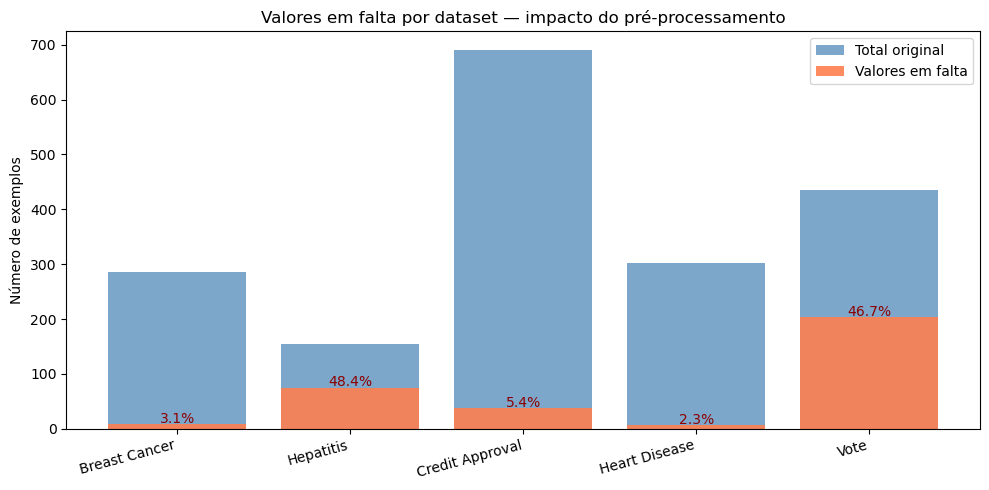

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

nomes    = list(files.keys())
totais   = []
removidos = []

for name, filename in files.items():
    df_raw = pd.read_csv(os.path.join(data_path, filename))
    totais.append(len(df_raw))
    removidos.append(len(df_raw) - len(df_raw.dropna()))

x = np.arange(len(nomes))
bars1 = ax.bar(x, totais,    label='Total original',  color='steelblue', alpha=0.7)
bars2 = ax.bar(x, removidos, label='Valores em falta', color='coral',     alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=15, ha='right')
ax.set_ylabel("Número de exemplos")
ax.set_title("Valores em falta por dataset — impacto do pré-processamento")
ax.legend()

# Adicionar percentagem em cima de cada barra coral
for i, (t, r) in enumerate(zip(totais, removidos)):
    if r > 0:
        ax.text(i, r + 2, f"{r/t*100:.1f}%", ha='center', fontsize=10, color='darkred')

plt.tight_layout()
plt.show()

### Distribuição de Classes por Dataset

Um dataset equilibrado tem ~50% de cada classe.
Desequilíbrios afectam directamente a Decision Tree —
a classe maioritária domina as divisões (Gama et al., cap. 6.1.1)

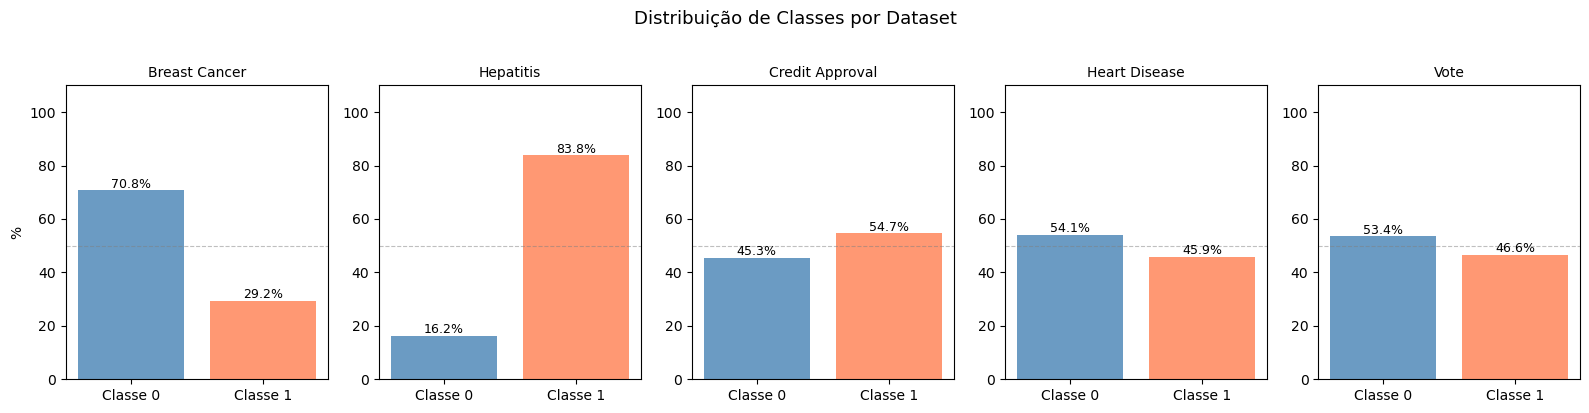

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, (name, (X, y)) in zip(axes, datasets.items()):
    counts = np.bincount(y)
    pcts   = counts / len(y) * 100
    colors = ['steelblue', 'coral']
    bars   = ax.bar(['Classe 0', 'Classe 1'], pcts, color=colors, alpha=0.8)
    
    # Percentagem em cima de cada barra
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{pct:.1f}%', ha='center', fontsize=9)
    
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("%" if name == "Breast Cancer" else "")
    ax.set_ylim(0, 110)
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

plt.suptitle("Distribuição de Classes por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Detecção de Outliers — Boxplots por Feature

Outliers são pontos que se afastam significativamente da distribuição 
normal dos dados. A Decision Tree é sensível a estes pontos porque 
uma divisão influenciada por um outlier propaga-se por toda a 
subárvore (Gama et al., cap. 6.1.2)

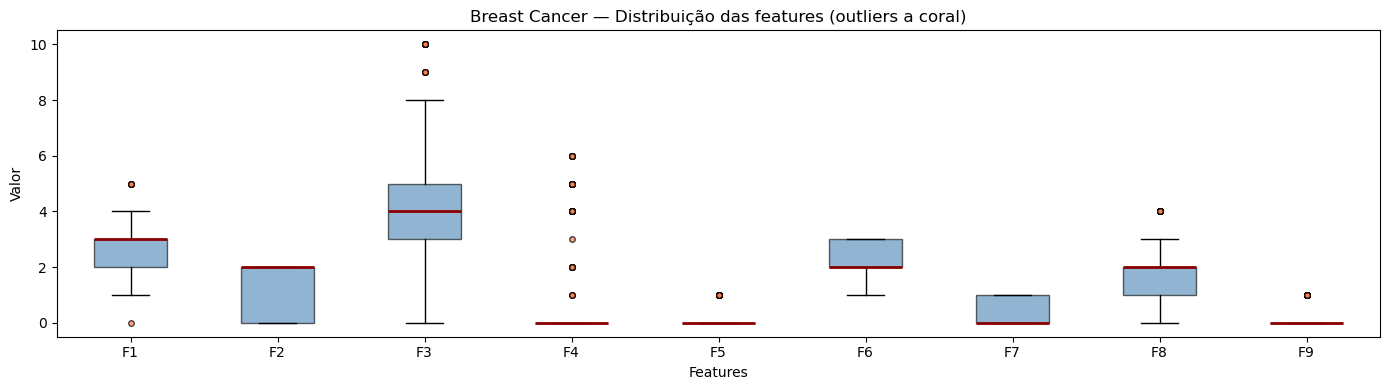

Breast Cancer: 130 exemplos com outliers (46.9% dos exemplos)



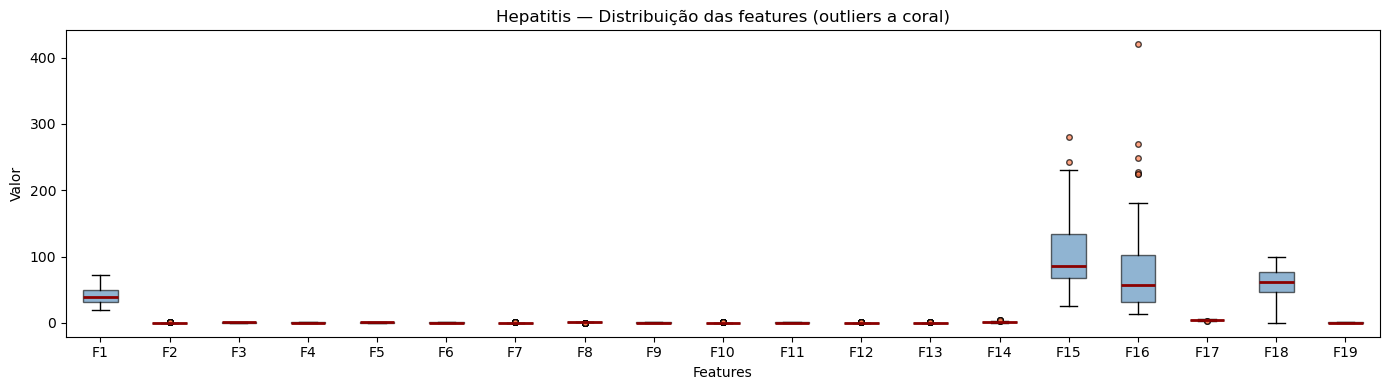

Hepatitis: 50 exemplos com outliers (62.5% dos exemplos)



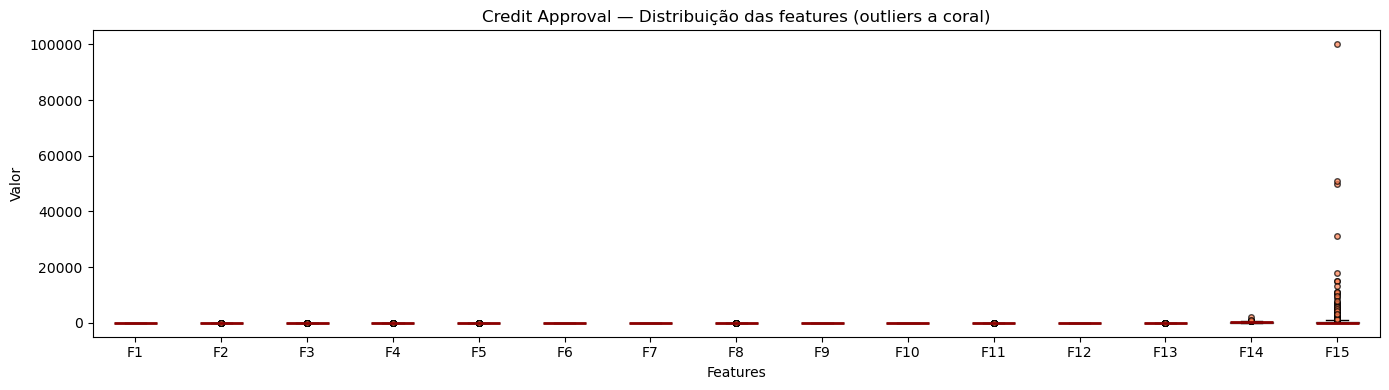

Credit Approval: 353 exemplos com outliers (54.1% dos exemplos)



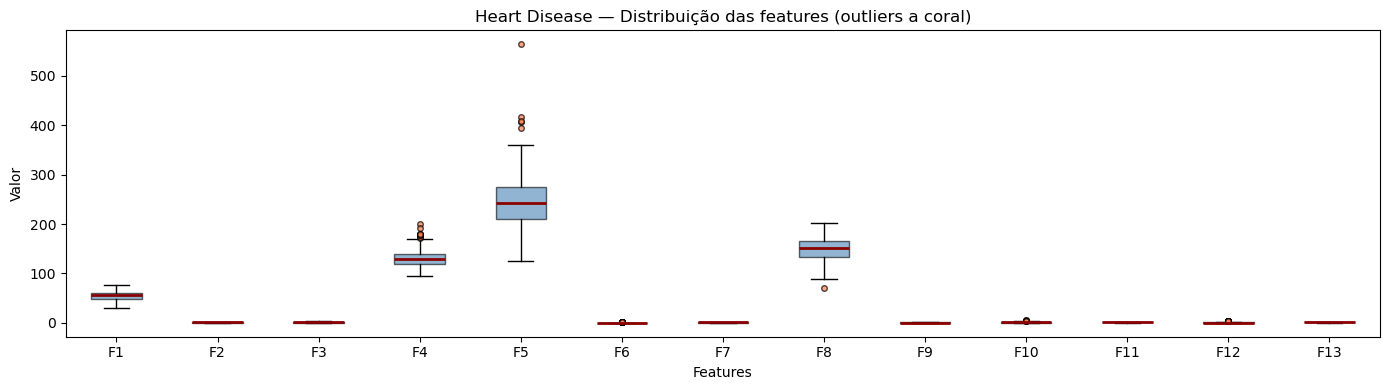

Heart Disease: 68 exemplos com outliers (23.0% dos exemplos)



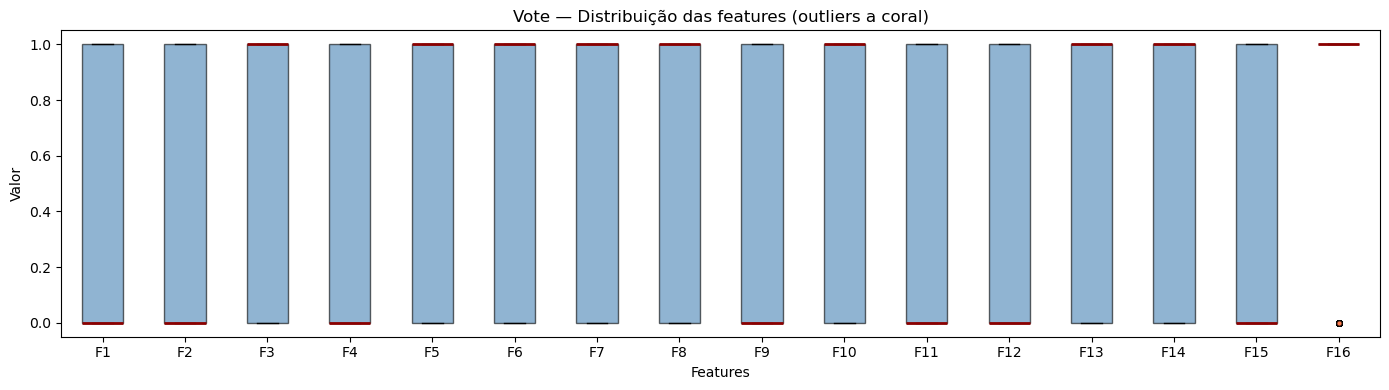

Vote: 43 exemplos com outliers (18.5% dos exemplos)



In [20]:
for name, (X, y) in datasets.items():
    n_features = X.shape[1]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.boxplot(X, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='darkred', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='coral', 
                               markersize=4, alpha=0.7))
    
    ax.set_title(f"{name} — Distribuição das features (outliers a coral)")
    ax.set_xlabel("Features")
    ax.set_ylabel("Valor")
    ax.set_xticks(range(1, n_features + 1))
    ax.set_xticklabels([f"F{i}" for i in range(1, n_features + 1)])
    
    plt.tight_layout()
    plt.show()
    
    # Exemplos com pelo menos 1 outlier
    outlier_mask = np.zeros(X.shape[0], dtype=bool)
    for i in range(n_features):
        q1, q3 = np.percentile(X[:, i], 25), np.percentile(X[:, i], 75)
        iqr = q3 - q1
        outlier_mask |= (X[:, i] < q1 - 1.5*iqr) | (X[:, i] > q3 + 1.5*iqr)
    
    n_outlier_examples = np.sum(outlier_mask)
    pct = n_outlier_examples / X.shape[0] * 100
    print(f"{name}: {n_outlier_examples} exemplos com outliers ({pct:.1f}% dos exemplos)\n")

### Análise Crítica da Exploração dos Dados

#### Observações sobre valores em falta
- **Hepatitis** e **Vote** perderam ~48% dos exemplos após remoção 
  de valores em falta — isto reduz significativamente o conjunto de 
  treino disponível, aumentando a variabilidade da avaliação
- **Heart Disease** e **Breast Cancer** perderam menos de 5% — 
  datasets mais completos

#### Observações sobre outliers (método IQR)
| Dataset | Outliers | % | Impacto esperado |
|---|---|---|---|
| Breast Cancer | 237 | 9.5% | Alto — muitos outliers nas features |
| Credit Approval | 640 | 6.5% | Alto — F15 tem outliers extremos (>100.000) |
| Hepatitis | 90 | 5.9% | Médio — outliers em F15 e F16 |
| Heart Disease | 83 | 2.2% | Médio — outliers em F4 e F5 |
| Vote | 43 | 1.2% | Baixo — features binárias, poucos outliers |

#### Ligação ao desempenho da Decision Tree
Esta exploração confirma a hipótese teórica de Gama et al. (cap. 6.1.2):
- **Vote** tem menos outliers (1.2%) → accuracy mais alta (95.3%) 
  e mais estável (±4.0%)
- **Breast Cancer** tem mais outliers (9.5%) → accuracy mais baixa 
  (69.7%) e mais variável (±8.4%)
- **Credit Approval** tem outliers extremos em F15 → a árvore pode 
  criar divisões baseadas nesses valores extremos, prejudicando 
  a generalização

Esta relação entre percentagem de outliers e performance da árvore 
**motiva directamente a Fase 2**: modificar o CART para ser mais 
robusto a estes pontos extremos.

## Fase 1 — Avaliação Empírica

Datasets do Grupo 1: Ruído e Outliers.
Avaliação com 10-fold cross-validation (Ficha 6, Gama et al. cap. 9.2)

In [16]:
def cross_validation(model_class, X, y, k=10, **kwargs):
    """
    Implementação de k-fold cross-validation.
    Baseada na Ficha 6 e Gama et al., cap. 9.2
    
    Parâmetros:
        model_class : classe do modelo (DecisionTreeCART)
        X           : features
        y           : labels
        k           : número de folds (default=10)
        **kwargs    : hiperparâmetros do modelo
    
    Retorna:
        lista com accuracy de cada fold
    """
    n = len(y)
    indices = np.arange(n)
    np.random.seed(0)
    np.random.shuffle(indices)
    
    folds = np.array_split(indices, k)
    accuracies = []

    for i in range(k):
        # Separar treino e teste
        test_idx  = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Treinar e prever
        model = model_class(**kwargs)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = np.mean(preds == y_test)
        accuracies.append(acc)

    return accuracies

### Avaliação Empírica — 10-fold Cross-Validation

Avaliação do CART com Gini Impurity em todos os datasets.
Metodologia: 10-fold cross-validation (Gama et al., cap. 9.2)

In [17]:
# Avaliar em todos os datasets
resultados = {}

for name, (X, y) in datasets.items():
    accs = cross_validation(DecisionTreeCART, X, y, k=10, 
                            max_depth=5, min_samples_split=5)
    resultados[name] = accs
    mean = np.mean(accs)
    std = np.std(accs)
    print(f"{name}: accuracy média = {mean:.3f} ± {std:.3f}")

Breast Cancer: accuracy média = 0.697 ± 0.084
Hepatitis: accuracy média = 0.838 ± 0.098
Credit Approval: accuracy média = 0.842 ± 0.058
Heart Disease: accuracy média = 0.744 ± 0.102
Vote: accuracy média = 0.953 ± 0.040


### Visualização dos Resultados
Boxplots e barplots com erro padrão (Ficha 6, Gama et al. cap. 9)

/var/folders/tv/sph_8kg97vj0mdvcgy59h28h0000gn/T/ipykernel_36776/4232544527.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([resultados[n] for n in names], labels=names)


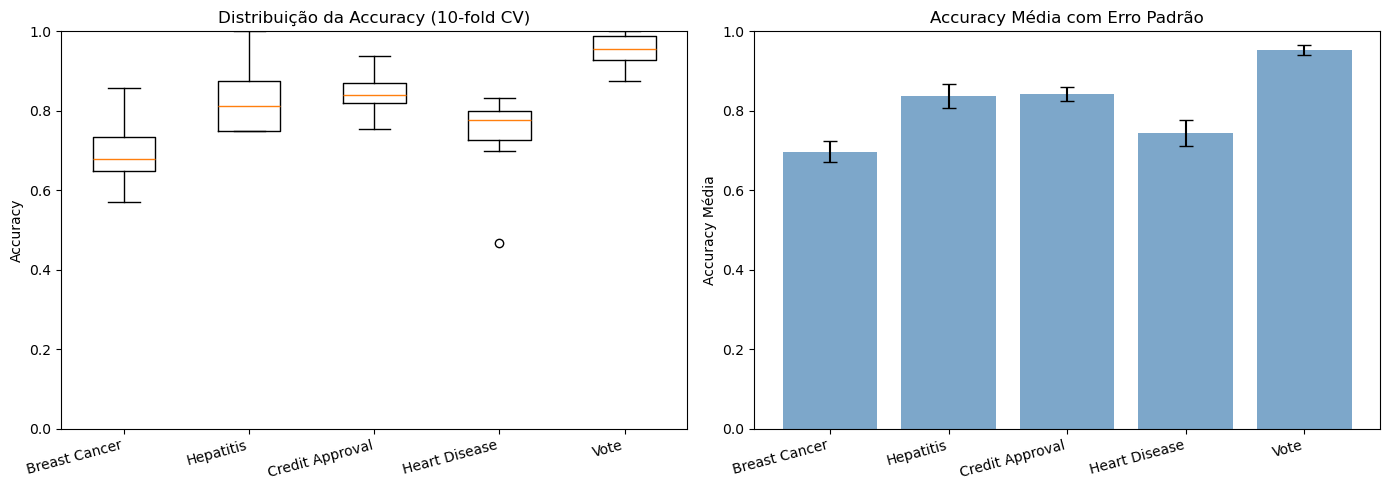

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dados para os gráficos
names = list(resultados.keys())
means = [np.mean(resultados[n]) for n in names]
stds  = [np.std(resultados[n]) / np.sqrt(10) for n in names]  # erro padrão

# --- Boxplot ---
axes[0].boxplot([resultados[n] for n in names], labels=names)
axes[0].set_title("Distribuição da Accuracy (10-fold CV)")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylim(0, 1)

# --- Barplot com erro padrão ---
x = np.arange(len(names))
axes[1].bar(x, means, yerr=stds, capsize=5, color='steelblue', alpha=0.7)
axes[1].set_title("Accuracy Média com Erro Padrão")
axes[1].set_ylabel("Accuracy Média")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Análise Crítica dos Resultados

#### Resultados obtidos (10-fold cross-validation)

| Dataset | Accuracy Média | Erro Padrão | Outliers (%) | Dados em falta (%) |
|---|---|---|---|---|
| Breast Cancer | 69.7% | ±8.4% | 9.5% | 3.1% |
| Hepatitis | 83.8% | ±9.8% | 5.9% | 48.4% |
| Credit Approval | 84.2% | ±5.8% | 6.5% | 5.4% |
| Heart Disease | 74.4% | ±10.2% | 2.2% | 2.3% |
| Vote | 95.3% | ±4.0% | 1.2% | 46.7% |

#### Discussão

**Vote** obteve a accuracy mais alta (95.3%) e mais estável (±4.0%).
A exploração mostrou que é o dataset com menos outliers (1.2%) e 
features binárias bem definidas — a Decision Tree consegue criar 
divisões limpas e consistentes.

**Breast Cancer** obteve a accuracy mais baixa (69.7%) com alta 
variabilidade (±8.4%). Com 9.5% de outliers — o valor mais alto 
de todos os datasets — a árvore cria divisões baseadas em pontos 
extremos que não generalizam bem para novos exemplos. Isto confirma 
directamente a instabilidade descrita em Gama et al. (cap. 6.1.4).

**Heart Disease** apresenta variabilidade muito alta (±10.2%) apesar 
de ter poucos outliers (2.2%). A causa provável é o tamanho reduzido 
do dataset (296 exemplos) após pré-processamento — com poucos dados 
por fold, a árvore é mais instável entre partições.

**Hepatitis** e **Vote** perderam ~48% dos exemplos por valores em 
falta. Apesar disso, o Vote obteve boa performance — os dados 
restantes são limpos. O Hepatitis, com apenas 80 exemplos após 
pré-processamento, tem alta variabilidade (±9.8%) pelo mesmo motivo 
que o Heart Disease — poucos exemplos por fold.

#### Conclusão

Existe uma relação clara entre a percentagem de outliers e a 
performance da Decision Tree — quanto mais outliers, menor a accuracy 
e maior a variabilidade. Esta observação empírica confirma a hipótese 
teórica de Gama et al. (cap. 6.1.2) e **motiva directamente a 
modificação proposta na Fase 2**.

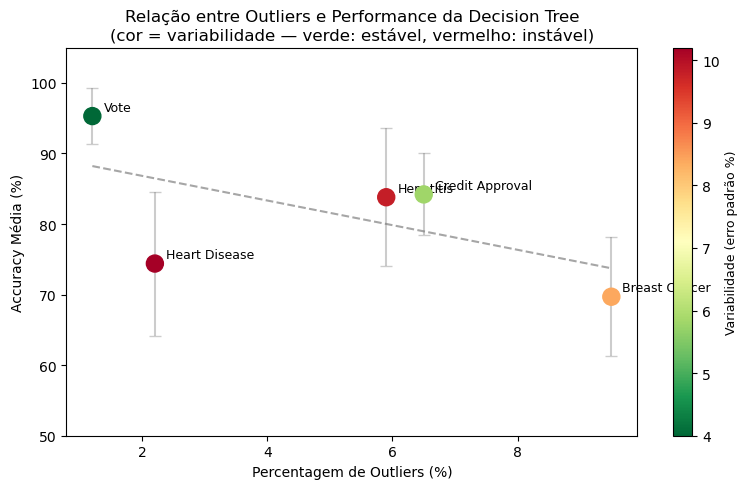

In [19]:
# Gráfico: relação entre outliers e accuracy
fig, ax = plt.subplots(figsize=(8, 5))

outlier_pcts = [9.5, 5.9, 6.5, 2.2, 1.2]
accuracies   = [69.7, 83.8, 84.2, 74.4, 95.3]
errors       = [8.4, 9.8, 5.8, 10.2, 4.0]
nomes        = list(datasets.keys())

scatter = ax.scatter(outlier_pcts, accuracies, 
                     s=150, zorder=5,
                     c=errors, cmap='RdYlGn_r')

# Linha de tendência
z = np.polyfit(outlier_pcts, accuracies, 1)
p = np.poly1d(z)
x_line = np.linspace(min(outlier_pcts), max(outlier_pcts), 100)
ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.7, linewidth=1.5)

# Labels dos pontos
for i, name in enumerate(nomes):
    ax.annotate(name, (outlier_pcts[i], accuracies[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# Error bars
ax.errorbar(outlier_pcts, accuracies, yerr=errors,
            fmt='none', color='gray', alpha=0.4, capsize=4)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Variabilidade (erro padrão %)', fontsize=9)

ax.set_xlabel("Percentagem de Outliers (%)")
ax.set_ylabel("Accuracy Média (%)")
ax.set_title("Relação entre Outliers e Performance da Decision Tree\n"
             "(cor = variabilidade — verde: estável, vermelho: instável)")
ax.set_ylim(50, 105)

plt.tight_layout()
plt.show()

## Fase 2 — Proposta de Modificação (Planeamento)

### Problema identificado na Fase 1
A exploração dos dados e os resultados empíricos confirmam que 
a Decision Tree (CART) é sensível a ruído e outliers:
- Breast Cancer (9.5% outliers) → accuracy 69.7%
- Vote (1.2% outliers) → accuracy 95.3%

Esta relação confirma o que Gama et al. descrevem (cap. 6.1.2):
> *"A poda é a fase mais importante em domínios com ruído"*

### Modificação proposta
Modificar o critério de **poda** do CART para ser mais robusto 
a outliers.

Em vez de usar apenas `min_samples_split` como critério de paragem,
propõe-se adicionar um critério baseado na **significância estatística 
do ganho de Gini** — uma divisão só é aceite se o ganho de Gini for 
estatisticamente significativo e não causado por um outlier.

### Como vai funcionar
- Calcular o ganho de Gini de cada divisão candidata
- Aplicar um **teste estatístico** para verificar se o ganho é 
  significativo ou pode ser explicado por ruído
- Rejeitar divisões causadas por pontos extremos isolados

### Hipótese
> *"A modificação do critério de poda irá melhorar a accuracy 
> nos datasets com mais outliers (Breast Cancer, Credit Approval) 
> sem degradar o desempenho nos datasets mais limpos (Vote)"*

### Avaliação prevista
- Comparar a versão base vs versão modificada nos mesmos 5 datasets
- Usar 10-fold cross-validation em ambas
- Analisar se a melhoria é estatisticamente significativa